In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(r'D:\study\online_fraud_detection.csv')

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## General EDA

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,"6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00"
mean,243.40,"179,861.90","833,883.10","855,113.67","1,100,701.67","1,224,996.40",0.00,0.00
std,142.33,"603,858.23","2,888,242.67","2,924,048.50","3,399,180.11","3,674,128.94",0.04,0.00
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,156.00,"13,389.57",0.00,0.00,0.00,0.00,0.00,0.00
50%,239.00,"74,871.94","14,208.00",0.00,"132,705.66","214,661.44",0.00,0.00
75%,335.00,"208,721.48","107,315.18","144,258.41","943,036.71","1,111,909.25",0.00,0.00
max,743.00,"92,445,516.64","59,585,040.37","49,585,040.37","356,015,889.35","356,179,278.92",1.00,1.00


In [6]:
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["isFraud"].value_counts(normalize=True)

isFraud
0   1.00
1   0.00
Name: proportion, dtype: float64

### EDA by type

In [15]:
target_summary = (
    df["isFraud"]
    .value_counts()
    .rename_axis("isFraud")
    .reset_index(name="count")
)

target_summary["percentage"] = target_summary["count"] / len(df) * 100

target_summary

,isFraud,count,percentage
0,0,6354407,99.87
1,1,8213,0.13


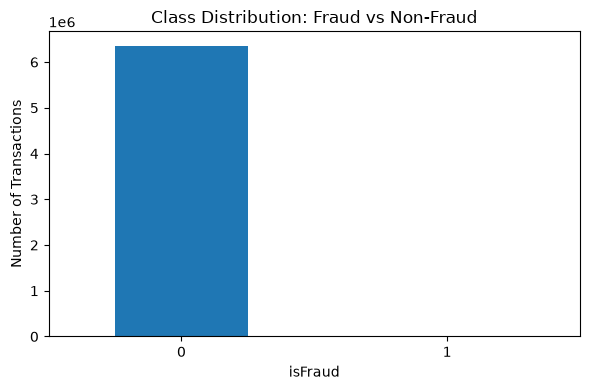

In [16]:
plt.figure(figsize=(6, 4))
target_summary.set_index("isFraud")["count"].plot(kind="bar")
plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("isFraud")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
type_summary = (
    df.groupby("type")
      .agg(
          total_transactions=("isFraud", "size"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean"),
          total_amount=("amount", "sum"),
        #   avg_amount=("amount", "mean"),
        #   median_amount=("amount", "median"),
        #   max_amount=("amount", "max")
      )
      .reset_index()
)

type_summary["fraud_rate_pct"] = type_summary["fraud_rate"] * 100
type_summary["transaction_share_pct"] = (
    type_summary["total_transactions"] / len(df) * 100
)

type_summary["fraud_share_pct"] = (
    type_summary["fraud_count"] / df["isFraud"].sum() * 100
)

type_summary = type_summary.sort_values("fraud_rate_pct", ascending=False)

type_summary

,type,total_transactions,fraud_count,fraud_rate,total_amount,fraud_rate_pct,transaction_share_pct,fraud_share_pct
4,TRANSFER,532909,4097,0.01,"485,291,987,263.17",0.77,8.38,49.88
1,CASH_OUT,2237500,4116,0.00,"394,412,995,224.49",0.18,35.17,50.12
0,CASH_IN,1399284,0,0.00,"236,367,391,912.46",0.00,21.99,0.00
2,DEBIT,41432,0,0.00,"227,199,221.28",0.00,0.65,0.00
3,PAYMENT,2151495,0,0.00,"28,093,371,138.37",0.00,33.81,0.00


### EDA with numeric

In [10]:
amount_stats = df["amount"].describe(
    percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
)

amount_stats

count    6,362,620.00
mean       179,861.90
std        603,858.23
min              0.00
1%             449.47
5%           2,224.10
10%          4,501.30
25%         13,389.57
50%         74,871.94
75%        208,721.48
90%        365,423.31
95%        518,634.20
99%      1,615,979.47
99.9%    8,956,797.68
max     92,445,516.64
Name: amount, dtype: float64

The amount distribution is highly right-skewed. The median transaction amount is much lower than the mean, while the 99.9th percentile and maximum values are extremely large. Therefore, log transformation is required for visualization and modeling.

In [11]:
df["log_amount"] = np.log1p(df["amount"])

Because transaction amount has a long-tailed distribution, log(amount + 1) was used for visualization and later feature engineering. This transformation compresses extreme values while preserving the relative ordering of transaction amounts.

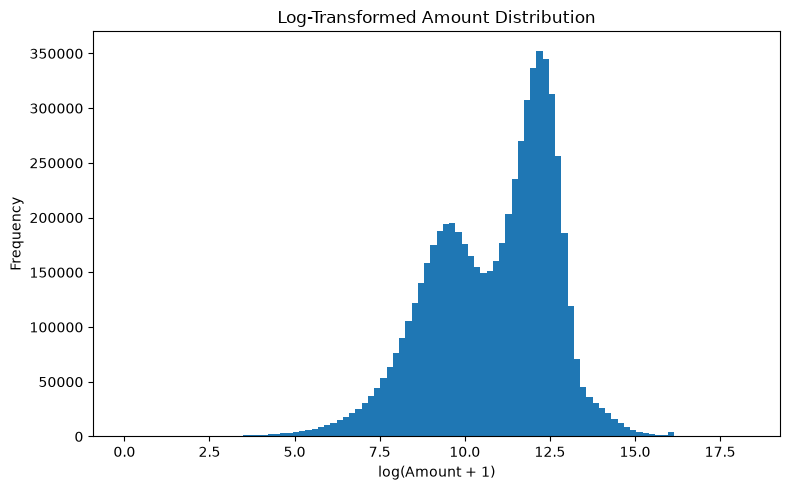

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["log_amount"], bins=100)
plt.title("Log-Transformed Amount Distribution")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("../figures/log_amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

<Axes: xlabel='isFraud', ylabel='log_amount'>

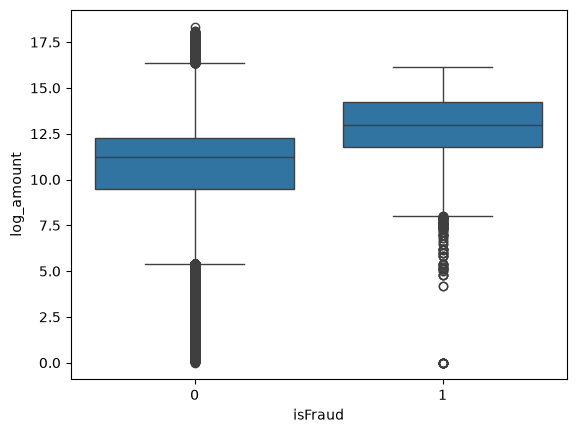

In [13]:
sns.boxplot(x="isFraud", y="log_amount", data=df)